# Weather-condition model comparison

This notebook compares interpolation, U-Net, and Transformer performance under different JJA weather regimes. It uses variables already available in the project: high-resolution Tmax truth, ERA5 dew point, and ERA5 surface solar radiation.

Available regimes here: hot/cool days, humid/dry days, cloudy/sunny days, and combined regimes such as hot-cloudy and hot-humid. Rainy and windy regimes require additional precipitation and wind files.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 130,
})

fig_dir = Path("../figures/weather_condition_compare")
fig_dir.mkdir(parents=True, exist_ok=True)

test_path = "../.data/downscaling_splits/test_norm.nc"
extra_path = "../.data/downscaling_splits_extra/test_extra_norm.nc"
unet_path = "../outputs/test_predictions.nc"
transformer_path = "../outputs/test_predictions_transformer_t_elev_oscar.nc"

ds_test = xr.open_dataset(test_path)
ds_extra = xr.open_dataset(extra_path)
ds_unet = xr.open_dataset(unet_path)
ds_tf = xr.open_dataset(transformer_path)

print(ds_test)
print(ds_extra)
print(ds_unet)
print(ds_tf)

<xarray.Dataset> Size: 552MB
Dimensions:             (time: 368, lat_coarse: 39, lon_coarse: 51, lat: 240,
                         lon: 311)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2022-06-01 ... 2025-08-31
  * lat_coarse          (lat_coarse) float64 312B 46.75 46.5 ... 37.5 37.25
  * lon_coarse          (lon_coarse) float64 408B -79.75 -79.5 ... -67.5 -67.25
  * lat                 (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon                 (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
Data variables:
    tmax_lowres         (time, lat_coarse, lon_coarse) float32 3MB ...
    tmax_highres        (time, lat, lon) float32 110MB ...
    valid_mask          (lat, lon) int8 75kB ...
    tmax_lowres_interp  (time, lat, lon) float32 110MB ...
    tmax_residual       (time, lat, lon) float32 110MB ...
    x_norm              (time, lat, lon) float32 110MB ...
    y_norm              (time, lat, lon) float32 110MB ...
Attributes:
    descr

In [2]:
pred_var = "pred_tmax_highres"
truth_var = "tmax_highres"
interp_var = "tmax_lowres_interp"
mask_var = "valid_mask"

common_time = np.intersect1d(ds_unet["time"].values, ds_tf["time"].values)
common_time = np.intersect1d(common_time, ds_test["time"].values)
common_time = np.intersect1d(common_time, ds_extra["time"].values)

truth = ds_test[truth_var].sel(time=common_time)
interp = ds_test[interp_var].sel(time=common_time)
unet = ds_unet[pred_var].sel(time=common_time)
tf = ds_tf[pred_var].sel(time=common_time)
mask = ds_test[mask_var].astype(bool)

d2m = ds_extra["d2m_lowres_interp"].sel(time=common_time)
ssrd = ds_extra["ssrd_lowres_interp"].sel(time=common_time)

def kelvin_to_celsius_if_needed(da):
    # Use NumPy nanmean here because these NetCDF files can give misleading xarray means
    # after masking, while the decoded values themselves are correct.
    vals = da.where(mask).values if {"lat", "lon"}.issubset(da.dims) else da.values
    val = float(np.nanmean(vals))
    return da - 273.15 if val > 100 else da

truth = kelvin_to_celsius_if_needed(truth)
interp = kelvin_to_celsius_if_needed(interp)
unet = kelvin_to_celsius_if_needed(unet)
tf = kelvin_to_celsius_if_needed(tf)
d2m = kelvin_to_celsius_if_needed(d2m)

# Surface solar radiation in MJ m-2 day-1 for easier interpretation.
ssrd_mj = ssrd / 1e6

models = {
    "Interpolation": interp,
    "U-Net T+Elev": unet,
    "Transformer T+Elev": tf,
}

print("Number of test days:", len(common_time))
print("Temperature unit after conversion: deg C")

Number of test days: 368
Temperature unit after conversion: deg C


In [3]:
def daily_masked_mean(da, mask):
    arr = da.where(mask).values
    return np.nanmean(arr, axis=(1, 2))

def daily_rmse(pred, truth, mask):
    return np.sqrt(daily_masked_mean((pred - truth) ** 2, mask))

def daily_mae(pred, truth, mask):
    return daily_masked_mean(np.abs(pred - truth), mask)

def daily_bias(pred, truth, mask):
    return daily_masked_mean(pred - truth, mask)

def daily_spatial_corr(pred, truth, mask):
    mask2d = mask.values.astype(bool)
    corrs = []
    for i in range(truth.sizes["time"]):
        x = pred.isel(time=i).values
        y = truth.isel(time=i).values
        valid = mask2d & np.isfinite(x) & np.isfinite(y)
        if valid.sum() < 2 or np.std(x[valid]) == 0 or np.std(y[valid]) == 0:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(x[valid], y[valid])[0, 1])
    return xr.DataArray(corrs, coords={"time": truth["time"]}, dims=("time",))

def domain_mean(da, mask=None):
    if mask is not None and {"lat", "lon"}.issubset(da.dims):
        arr = da.where(mask).values
    else:
        arr = da.values
    return np.nanmean(arr, axis=(1, 2))

def daily_spatial_quantile(da, q, mask):
    arr = da.where(mask).values
    return np.nanquantile(arr, q, axis=(1, 2))

daily = pd.DataFrame(index=pd.to_datetime(common_time))

for name, pred in models.items():
    daily[f"{name} RMSE"] = daily_rmse(pred, truth, mask)
    daily[f"{name} MAE"] = daily_mae(pred, truth, mask)
    daily[f"{name} Bias"] = daily_bias(pred, truth, mask)
    daily[f"{name} Spatial corr"] = daily_spatial_corr(pred, truth, mask).values

daily["Truth Tmax mean (deg C)"] = domain_mean(truth, mask)
daily["Truth Tmax p95 (deg C)"] = daily_spatial_quantile(truth, 0.95, mask)
daily["Dew point mean (deg C)"] = domain_mean(d2m, mask)
daily["Solar radiation mean (MJ m-2 day-1)"] = domain_mean(ssrd_mj, mask)

daily["U-Net minus Transformer RMSE"] = daily["U-Net T+Elev RMSE"] - daily["Transformer T+Elev RMSE"]
daily["Transformer beats U-Net"] = daily["Transformer T+Elev RMSE"] < daily["U-Net T+Elev RMSE"]
daily["U-Net beats interpolation"] = daily["U-Net T+Elev RMSE"] < daily["Interpolation RMSE"]
daily["Transformer beats interpolation"] = daily["Transformer T+Elev RMSE"] < daily["Interpolation RMSE"]

daily.head()

,Interpolation RMSE,Interpolation MAE,Interpolation Bias,Interpolation Spatial corr,U-Net T+Elev RMSE,U-Net T+Elev MAE,U-Net T+Elev Bias,U-Net T+Elev Spatial corr,Transformer T+Elev RMSE,Transformer T+Elev MAE,Transformer T+Elev Bias,Transformer T+Elev Spatial corr,Truth Tmax mean (deg C),Truth Tmax p95 (deg C),Dew point mean (deg C),Solar radiation mean (MJ m-2 day-1),U-Net minus Transformer RMSE,Transformer beats U-Net,U-Net beats interpolation,Transformer beats interpolation
2022-06-01,1.974516,1.570240,-0.802886,0.959668,1.854987,1.484120,-0.125186,0.959339,1.949048,1.598804,-0.214370,0.958298,24.254023,33.649994,14.048169,0.873483,-0.094061,False,True,True
2022-06-02,1.815732,1.392966,-1.002048,0.946260,1.114243,0.877365,-0.318328,0.971136,1.091479,0.854025,-0.353829,0.970387,24.257856,32.850006,14.729773,0.772775,0.022764,True,True,True
2022-06-03,1.660647,1.358530,-0.723761,0.907457,1.436130,1.105063,-0.024839,0.912903,1.348085,1.042498,-0.085355,0.923482,22.414560,26.649994,11.686384,0.919143,0.088045,True,True,True
2022-06-04,1.554300,1.199718,-0.676227,0.928666,0.971134,0.773734,-0.033606,0.964228,0.970089,0.771103,-0.062163,0.963872,23.392042,28.850006,8.827355,1.148710,0.001045,True,True,True
2022-06-05,1.599296,1.266139,-0.865474,0.910486,1.090893,0.863493,-0.220053,0.951932,0.948994,0.748003,-0.276567,0.955973,22.831129,26.550018,6.657612,1.158176,0.141899,True,True,True


In [4]:
def tercile_labels(series, low_name, mid_name, high_name):
    q1, q2 = series.quantile([1/3, 2/3])
    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, np.inf],
        labels=[low_name, mid_name, high_name],
        include_lowest=True,
    )

daily["Temperature regime"] = tercile_labels(
    daily["Truth Tmax mean (deg C)"], "Cool", "Moderate", "Hot"
)
daily["Humidity regime"] = tercile_labels(
    daily["Dew point mean (deg C)"], "Dry", "Moderate humidity", "Humid"
)
# Low solar radiation is used as a cloudy-day proxy.
daily["Cloud regime"] = tercile_labels(
    daily["Solar radiation mean (MJ m-2 day-1)"], "Cloudy", "Partly cloudy", "Sunny"
)

daily["Hot and cloudy"] = (daily["Temperature regime"] == "Hot") & (daily["Cloud regime"] == "Cloudy")
daily["Hot and humid"] = (daily["Temperature regime"] == "Hot") & (daily["Humidity regime"] == "Humid")
daily["Cool and cloudy"] = (daily["Temperature regime"] == "Cool") & (daily["Cloud regime"] == "Cloudy")

print("Temperature tercile counts")
print(daily["Temperature regime"].value_counts())
print("\nHumidity tercile counts")
print(daily["Humidity regime"].value_counts())
print("\nCloud regime tercile counts")
print(daily["Cloud regime"].value_counts())

Temperature tercile counts
Temperature regime
Cool        123
Hot         123
Moderate    122
Name: count, dtype: int64

Humidity tercile counts
Humidity regime
Dry                  123
Humid                123
Moderate humidity    122
Name: count, dtype: int64

Cloud regime tercile counts
Cloud regime
Cloudy           123
Sunny            123
Partly cloudy    122
Name: count, dtype: int64


In [5]:
metric_cols = [
    "Interpolation RMSE", "U-Net T+Elev RMSE", "Transformer T+Elev RMSE",
    "Interpolation MAE", "U-Net T+Elev MAE", "Transformer T+Elev MAE",
    "Interpolation Spatial corr", "U-Net T+Elev Spatial corr", "Transformer T+Elev Spatial corr",
]

def summarize_by_condition(condition_col):
    summary = daily.groupby(condition_col, observed=True)[metric_cols].mean()
    summary["n days"] = daily.groupby(condition_col, observed=True).size()
    summary["Transformer RMSE improvement vs U-Net"] = summary["U-Net T+Elev RMSE"] - summary["Transformer T+Elev RMSE"]
    summary["U-Net RMSE improvement vs interpolation"] = summary["Interpolation RMSE"] - summary["U-Net T+Elev RMSE"]
    summary["Transformer RMSE improvement vs interpolation"] = summary["Interpolation RMSE"] - summary["Transformer T+Elev RMSE"]
    return summary

temp_summary = summarize_by_condition("Temperature regime")
humid_summary = summarize_by_condition("Humidity regime")
cloud_summary = summarize_by_condition("Cloud regime")

display(temp_summary)
display(humid_summary)
display(cloud_summary)

,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation
Temperature regime,,,,,,,,,,,,,
Cool,1.486895,1.189354,1.151546,1.160315,0.938025,0.906356,0.890548,0.928448,0.931249,123,0.037807,0.297542,0.335349
Moderate,1.522271,1.039024,1.031321,1.175334,0.819947,0.812278,0.847239,0.920171,0.920496,122,0.007703,0.483246,0.490950
Hot,1.648057,1.174836,1.161728,1.244474,0.948486,0.932892,0.805253,0.895814,0.899382,123,0.013108,0.473222,0.486330


,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation
Humidity regime,,,,,,,,,,,,,
Dry,1.495970,1.091602,1.052986,1.155492,0.860064,0.825721,0.856840,0.917974,0.920875,123,0.038616,0.404368,0.442984
Moderate humidity,1.551463,1.105091,1.094960,1.193921,0.874163,0.864212,0.847852,0.918383,0.919948,122,0.010131,0.446372,0.456503
Humid,1.610029,1.207058,1.197167,1.230862,0.972672,0.962015,0.838353,0.908060,0.910299,123,0.009891,0.402971,0.412862


,Interpolation RMSE,U-Net T+Elev RMSE,Transformer T+Elev RMSE,Interpolation MAE,U-Net T+Elev MAE,Transformer T+Elev MAE,Interpolation Spatial corr,U-Net T+Elev Spatial corr,Transformer T+Elev Spatial corr,n days,Transformer RMSE improvement vs U-Net,U-Net RMSE improvement vs interpolation,Transformer RMSE improvement vs interpolation
Cloud regime,,,,,,,,,,,,,
Cloudy,1.548126,1.239770,1.239123,1.205704,0.978762,0.976127,0.886780,0.925779,0.926068,123,0.000647,0.308357,0.309003
Partly cloudy,1.515518,1.080725,1.056663,1.167230,0.856874,0.836992,0.844201,0.914383,0.916459,122,0.024062,0.434793,0.458856
Sunny,1.593524,1.083058,1.049016,1.207124,0.871123,0.838607,0.812035,0.904223,0.908567,123,0.034043,0.510466,0.544509


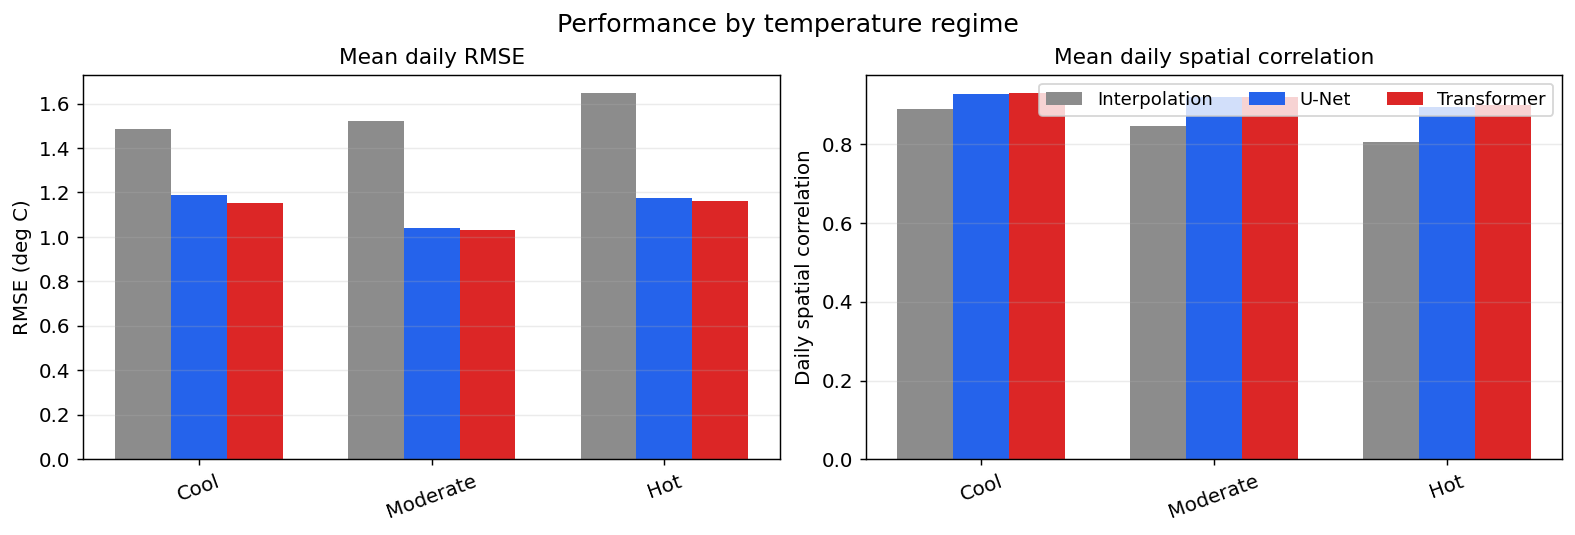

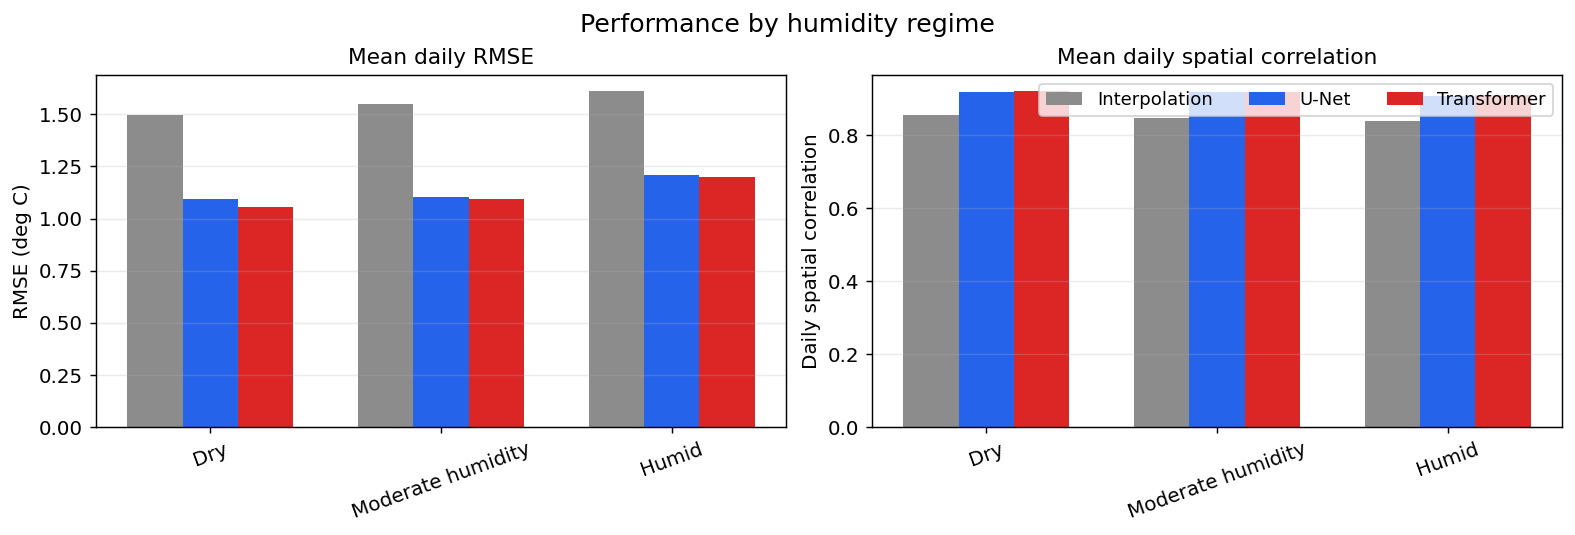

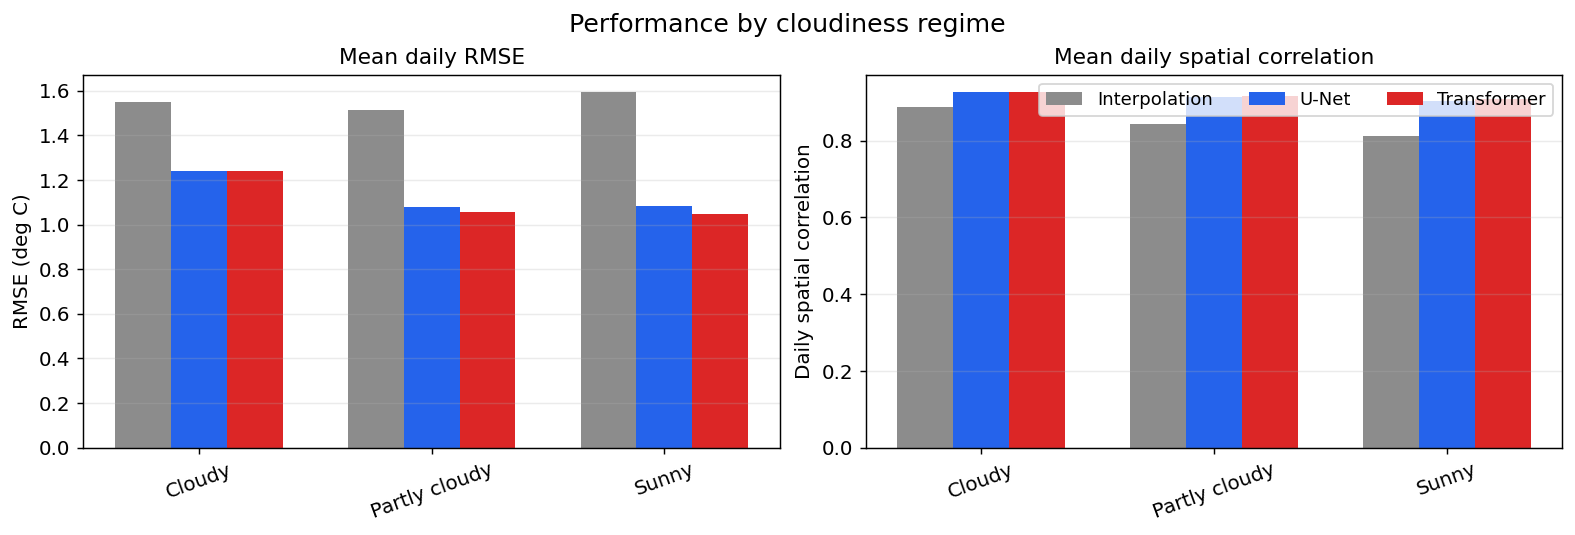

In [6]:
def plot_condition_bars(summary, title, filename):
    rmse_cols = ["Interpolation RMSE", "U-Net T+Elev RMSE", "Transformer T+Elev RMSE"]
    corr_cols = ["Interpolation Spatial corr", "U-Net T+Elev Spatial corr", "Transformer T+Elev Spatial corr"]
    labels = ["Interpolation", "U-Net", "Transformer"]
    colors = ["0.55", "#2563EB", "#DC2626"]

    x = np.arange(len(summary.index))
    width = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for i, (col, label, color) in enumerate(zip(rmse_cols, labels, colors)):
        axes[0].bar(x + (i - 1) * width, summary[col].values, width, label=label, color=color)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary.index, rotation=20)
    axes[0].set_ylabel("RMSE (deg C)")
    axes[0].set_title("Mean daily RMSE")
    axes[0].grid(axis="y", alpha=0.25)

    for i, (col, label, color) in enumerate(zip(corr_cols, labels, colors)):
        axes[1].bar(x + (i - 1) * width, summary[col].values, width, label=label, color=color)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary.index, rotation=20)
    axes[1].set_ylabel("Daily spatial correlation")
    axes[1].set_title("Mean daily spatial correlation")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(ncol=3)

    fig.suptitle(title, fontsize=14)
    plt.savefig(fig_dir / filename, bbox_inches="tight", dpi=300)
    plt.show()

plot_condition_bars(temp_summary, "Performance by temperature regime", "performance_by_temperature_regime.png")
plot_condition_bars(humid_summary, "Performance by humidity regime", "performance_by_humidity_regime.png")
plot_condition_bars(cloud_summary, "Performance by cloudiness regime", "performance_by_cloud_regime.png")

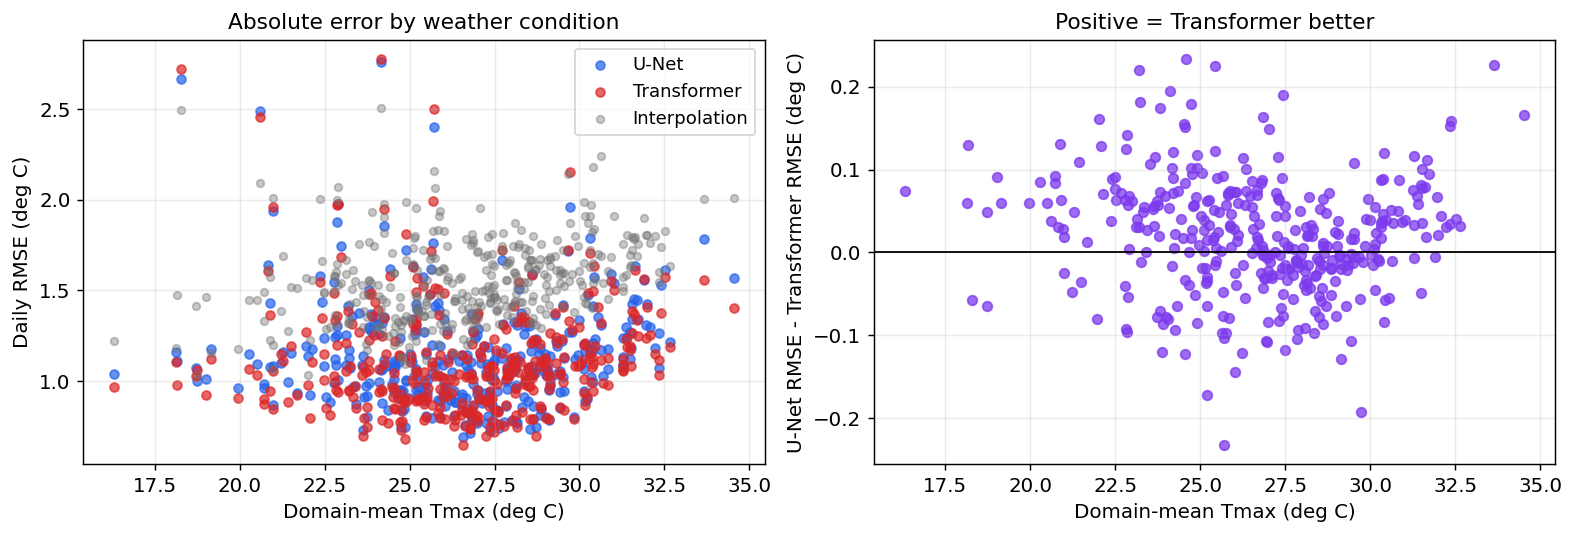

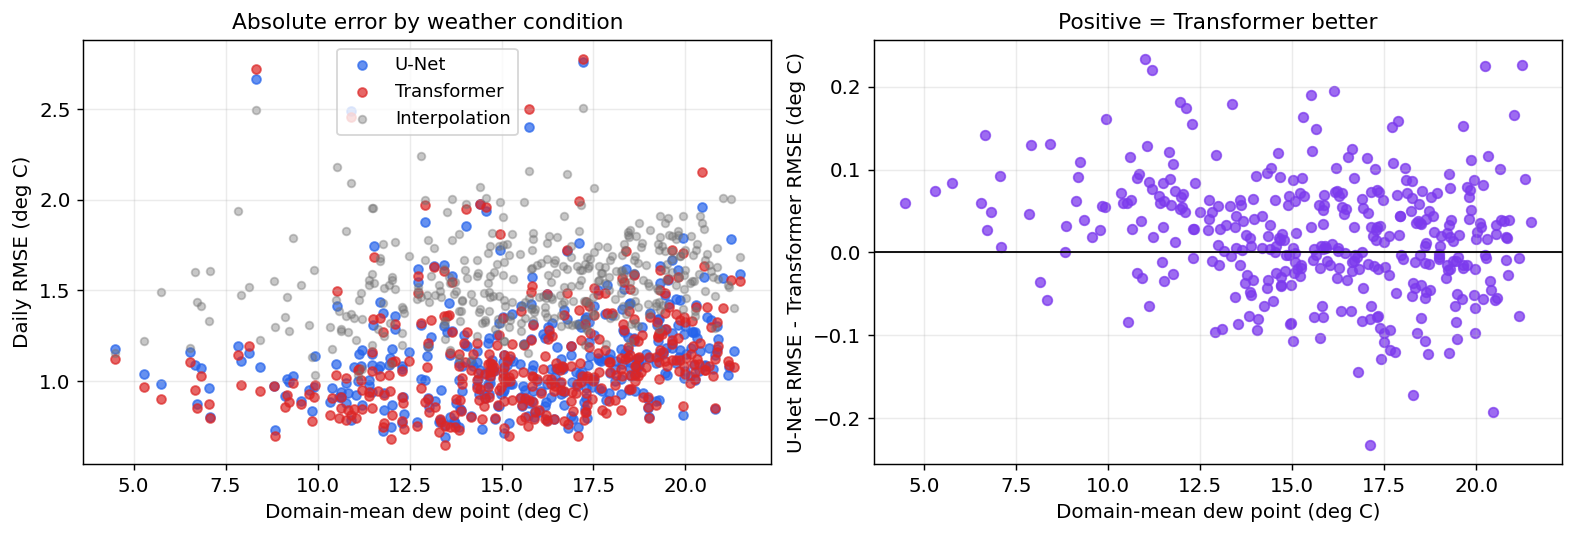

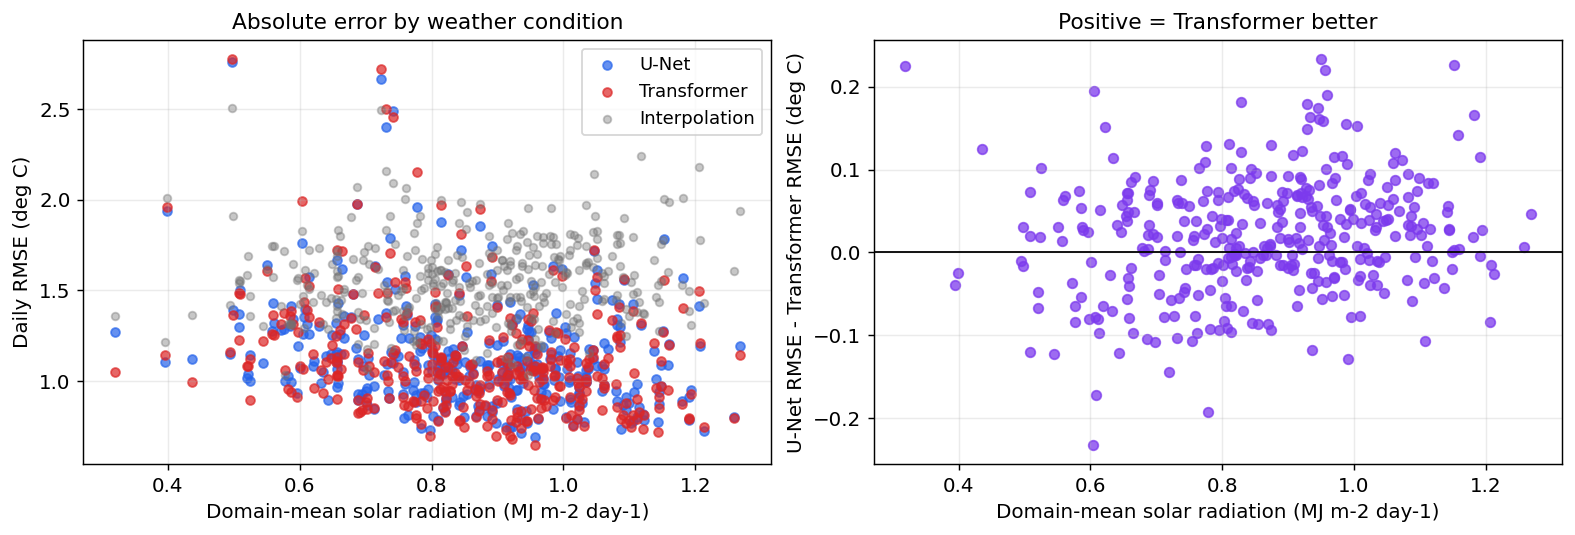

In [7]:
def plot_weather_scatter(xcol, xlabel, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].scatter(daily[xcol], daily["U-Net T+Elev RMSE"], s=24, alpha=0.7, label="U-Net", color="#2563EB")
    axes[0].scatter(daily[xcol], daily["Transformer T+Elev RMSE"], s=24, alpha=0.7, label="Transformer", color="#DC2626")
    axes[0].scatter(daily[xcol], daily["Interpolation RMSE"], s=18, alpha=0.4, label="Interpolation", color="0.45")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Daily RMSE (deg C)")
    axes[0].set_title("Absolute error by weather condition")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # Positive means Transformer is better than U-Net.
    axes[1].axhline(0, color="k", linewidth=1)
    axes[1].scatter(daily[xcol], daily["U-Net minus Transformer RMSE"], s=28, alpha=0.75, color="#7C3AED")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("U-Net RMSE - Transformer RMSE (deg C)")
    axes[1].set_title("Positive = Transformer better")
    axes[1].grid(alpha=0.25)

    plt.savefig(fig_dir / filename, bbox_inches="tight", dpi=300)
    plt.show()

plot_weather_scatter("Truth Tmax mean (deg C)", "Domain-mean Tmax (deg C)", "scatter_rmse_vs_temperature.png")
plot_weather_scatter("Dew point mean (deg C)", "Domain-mean dew point (deg C)", "scatter_rmse_vs_dewpoint.png")
plot_weather_scatter("Solar radiation mean (MJ m-2 day-1)", "Domain-mean solar radiation (MJ m-2 day-1)", "scatter_rmse_vs_solar.png")

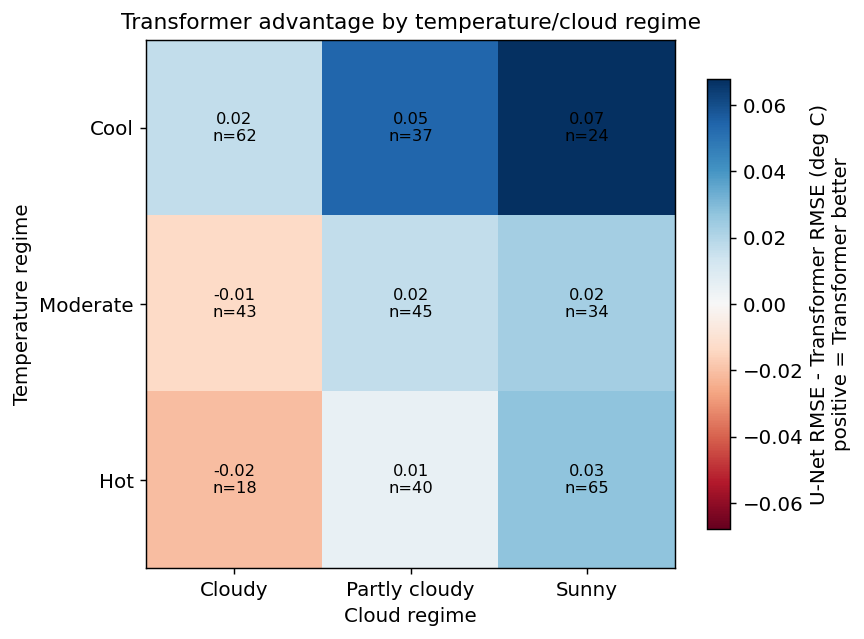

Cloud regime,Cloudy,Partly cloudy,Sunny
Temperature regime,,,
Cool,0.016765,0.053662,0.067724
Moderate,-0.013560,0.016469,0.022993
Hot,-0.020935,0.005225,0.027386


In [8]:
# Two-way regimes: where does Transformer beat U-Net?
two_way = daily.pivot_table(
    index="Temperature regime",
    columns="Cloud regime",
    values="U-Net minus Transformer RMSE",
    aggfunc="mean",
    observed=True,
)

count_two_way = daily.pivot_table(
    index="Temperature regime",
    columns="Cloud regime",
    values="U-Net minus Transformer RMSE",
    aggfunc="size",
    observed=True,
)

fig, ax = plt.subplots(figsize=(6.5, 4.8), constrained_layout=True)
vmax = np.nanmax(np.abs(two_way.values))
im = ax.imshow(two_way.values, cmap="RdBu", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(two_way.shape[1]))
ax.set_xticklabels(two_way.columns)
ax.set_yticks(np.arange(two_way.shape[0]))
ax.set_yticklabels(two_way.index)
ax.set_title("Transformer advantage by temperature/cloud regime")
ax.set_xlabel("Cloud regime")
ax.set_ylabel("Temperature regime")

for i in range(two_way.shape[0]):
    for j in range(two_way.shape[1]):
        val = two_way.values[i, j]
        n = count_two_way.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.2f}\nn={int(n)}", ha="center", va="center", fontsize=9)

cb = plt.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("U-Net RMSE - Transformer RMSE (deg C)\npositive = Transformer better")

plt.savefig(fig_dir / "transformer_advantage_temperature_cloud_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

two_way

In [9]:
# Cases where a learned model is worse than interpolation.
failure_summary = pd.DataFrame({
    "Condition": ["All days", "Hot", "Cool", "Cloudy", "Sunny", "Humid", "Dry", "Hot and cloudy", "Hot and humid"],
    "Mask": [
        np.ones(len(daily), dtype=bool),
        daily["Temperature regime"].eq("Hot"),
        daily["Temperature regime"].eq("Cool"),
        daily["Cloud regime"].eq("Cloudy"),
        daily["Cloud regime"].eq("Sunny"),
        daily["Humidity regime"].eq("Humid"),
        daily["Humidity regime"].eq("Dry"),
        daily["Hot and cloudy"],
        daily["Hot and humid"],
    ],
})

rows = []
for _, row in failure_summary.iterrows():
    sub = daily.loc[row["Mask"]]
    rows.append({
        "Condition": row["Condition"],
        "n days": len(sub),
        "U-Net worse than interpolation (%)": 100 * (~sub["U-Net beats interpolation"]).mean() if len(sub) else np.nan,
        "Transformer worse than interpolation (%)": 100 * (~sub["Transformer beats interpolation"]).mean() if len(sub) else np.nan,
        "Transformer beats U-Net (%)": 100 * sub["Transformer beats U-Net"].mean() if len(sub) else np.nan,
        "Mean U-Net RMSE": sub["U-Net T+Elev RMSE"].mean() if len(sub) else np.nan,
        "Mean Transformer RMSE": sub["Transformer T+Elev RMSE"].mean() if len(sub) else np.nan,
        "Mean interpolation RMSE": sub["Interpolation RMSE"].mean() if len(sub) else np.nan,
    })

failure_table = pd.DataFrame(rows)
display(failure_table)

failure_table.to_csv(fig_dir / "condition_failure_summary.csv", index=False)
daily.to_csv(fig_dir / "daily_weather_condition_metrics.csv")

,Condition,n days,U-Net worse than interpolation (%),Transformer worse than interpolation (%),Transformer beats U-Net (%),Mean U-Net RMSE,Mean Transformer RMSE,Mean interpolation RMSE
0,All days,368,4.076087,4.076087,61.141304,1.134664,1.115092,1.552490
1,Hot,123,0.813008,0.813008,55.284553,1.174836,1.161728,1.648057
2,Cool,123,9.756098,8.130081,73.983740,1.189354,1.151547,1.486895
3,Cloudy,123,8.130081,9.756098,54.471545,1.239770,1.239123,1.548126
4,Sunny,123,1.626016,0.813008,68.292683,1.083058,1.049016,1.593524
5,Humid,123,1.626016,2.439024,52.845528,1.207058,1.197167,1.610029
6,Dry,123,6.504065,4.878049,75.609756,1.091602,1.052986,1.495970
7,Hot and cloudy,18,5.555556,5.555556,33.333333,1.258386,1.279321,1.637280
8,Hot and humid,84,1.190476,1.190476,59.523810,1.238433,1.216674,1.653509


## Interpreting the results

- Use RMSE/MAE to discuss magnitude of temperature error.
- Use spatial correlation to discuss whether the model captures the regional pattern.
- In the Transformer-vs-U-Net plots, positive `U-Net RMSE - Transformer RMSE` means Transformer is better.
- Low solar radiation is a proxy for cloudy days, not direct cloud cover.
- Dew point is a humidity proxy. High dew point days are humid days.

For true rainy-day analysis, add daily precipitation. For windy-day analysis, add 10 m wind speed from ERA5 or another source.